In [1]:
!pip install pandas nltk textblob matplotlib wordcloud


In [2]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download necessary NLTK data packages
nltk.download('punkt')
nltk.download('stopwords')

# 1. Load the provided dataset
df = pd.read_csv("3) Sentiment dataset.csv")

# Set column configuration based on your file
TEXT_COL = 'Text' 

# 2. Text Preprocessing Function
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if pd.isna(text): 
        return ""
    text = str(text).lower()
    tokens = word_tokenize(text)
    cleaned_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(cleaned_tokens)

# Apply preprocessing
df['cleaned_review'] = df[TEXT_COL].apply(preprocess_text)
print("Preprocessing complete! Here is a preview:")
print(df[[TEXT_COL, 'cleaned_review']].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Preprocessing complete! Here is a preview:
                                                Text  \
0   Enjoying a beautiful day at the park!        ...   
1   Traffic was terrible this morning.           ...   
2   Just finished an amazing workout! 💪          ...   
3   Excited about the upcoming weekend getaway!  ...   
4   Trying out a new recipe for dinner tonight.  ...   

                     cleaned_review  
0       enjoying beautiful day park  
1          traffic terrible morning  
2          finished amazing workout  
3  excited upcoming weekend getaway  
4  trying new recipe dinner tonight  


In [3]:
from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(text)
    # Polarity ranges from -1 (Negative) to +1 (Positive)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Run sentiment analysis
df['TextBlob_Sentiment'] = df['cleaned_review'].apply(get_sentiment)

print("Comparison between Original Label and TextBlob Prediction:")
print(df[[TEXT_COL, 'Sentiment', 'TextBlob_Sentiment']].head(10))


Comparison between Original Label and TextBlob Prediction:
                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      
5   Feeling grateful for the little things in lif...   Positive     
6   Rainy days call for cozy blankets and hot coc...   Positive     
7   The new movie release is a must-watch!       ...   Positive     
8   Political discussions heating up on the timel...   Negative     
9   Missing summer vibes and beach days.         ...   Neutral      

  TextBlob_Sentiment  
0           Positive  
1           Negative  
2           Positive  
3           Positive  
4           Positive  
5           Negative  
6           Positive

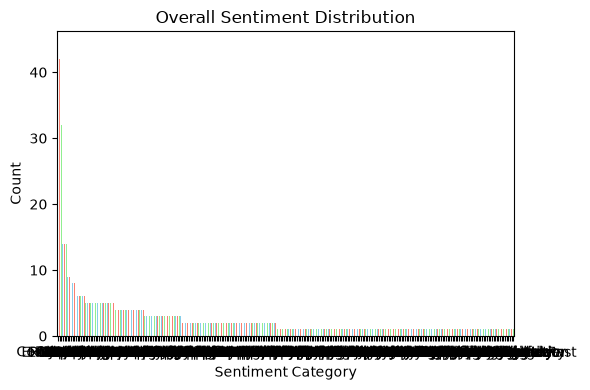

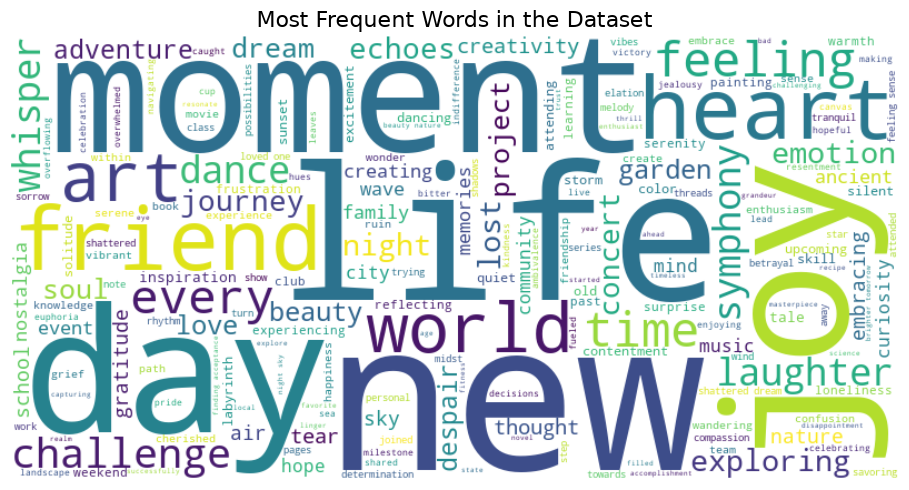

In [4]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. Plot original Sentiment Distribution from the file
plt.figure(figsize=(6, 4))
df['Sentiment'].value_counts().plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Generate and Plot the Word Cloud
all_words = " ".join(review for review in df['cleaned_review'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in the Dataset", fontsize=16)
plt.tight_layout()
plt.show()